# TI3145TU Midterm Assignment 
## Football Players Wages

We hope you enjoy this assignment, good luck!

Student names: XXX

Student numbers: XXX

### Imports

In [1]:
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

### Load data

In [2]:
# These are your training samples along with their labels
data = pd.read_csv('football_wages.csv')
print("features", data.columns)
data.info()


features Index(['age', 'height_cm', 'weight_kg', 'nationality_name', 'overall',
       'potential', 'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
       'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
       'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
       'movement_reactions', 'movement_balance', 'defending_standing_tackle',
       'defending_sliding_tackle', 'goalkeeping_diving',
       'goalkeeping_handling', 'goalkeeping_kicking',
       'goalkeeping_positioning', 'goalkeeping_reflexes', 'log_wages'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   float64
 1   height_cm     

In [3]:
data.head()

,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,log_wages
0,27.0,183.0,76.0,b'Korea Republic',57.0,58.0,54.0,30.0,55.0,53.0,...,60.0,67.0,63.0,58.0,9.0,13.0,8.0,11.0,10.0,3.000000
1,21.0,182.0,70.0,b'France',61.0,72.0,58.0,63.0,46.0,62.0,...,47.0,65.0,31.0,33.0,9.0,11.0,9.0,12.0,11.0,3.000000
2,35.0,182.0,75.0,b'Korea Republic',68.0,68.0,62.0,68.0,68.0,70.0,...,61.0,69.0,36.0,40.0,8.0,12.0,7.0,12.0,6.0,3.301030
3,29.0,169.0,70.0,b'Paraguay',67.0,67.0,62.0,55.0,50.0,71.0,...,59.0,84.0,40.0,55.0,6.0,10.0,11.0,15.0,9.0,2.698970
4,30.0,176.0,74.0,b'Austria',65.0,65.0,63.0,49.0,53.0,63.0,...,58.0,75.0,65.0,64.0,12.0,15.0,10.0,8.0,10.0,3.477121


In [258]:
# You need to extract the features and the regression target. The regression target is 'log_wages'. 
from sklearn.decomposition import PCA
from sklearn.preprocessing import TargetEncoder
from sklearn.base import BaseEstimator, TransformerMixin

def categorical_features(X):
     return X.select_dtypes(include=['object']).columns

class flipKeepers(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        return None
    
    def fit(self, X, y=None):
        # Nothing to learn, so just return self
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns = self.columns)
        X_copy = X.copy()
        for col in [col for col in X.columns if 'goalkeeping' in col]:   
            avg = X[col].mean()
            X[col] = 2*avg - X_copy[col]
        return X


regression_target_Y = data["log_wages"]
features_X = data.drop(["log_wages"], axis=1)

numerical_features_X = features_X.columns

# https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html#
# A1) Basic Pipeline: (standardization of data)
categorical_transformer = ColumnTransformer(transformers=[
    ('target', TargetEncoder(), categorical_features)  
], remainder='passthrough')
preprocesser_dumb = Pipeline([
    ('categorical', categorical_transformer)
])
preprocesser_simple = Pipeline([
    ('categorical', categorical_transformer),
    ('numerical', StandardScaler())
])
preprocesser_flip = Pipeline([
    ('categorical', categorical_transformer),
    ('flip', flipKeepers(numerical_features_X)),
    ('numerical', StandardScaler())
])
preprocesser_pca = Pipeline([
    ('categorical', categorical_transformer),
    ('numerical', StandardScaler()),
    ('pca', PCA(n_components=0.95))
])

<Figure size 640x480 with 0 Axes>

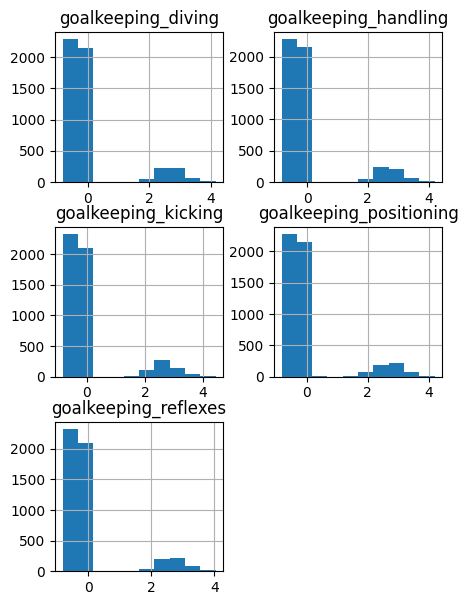

<Figure size 640x480 with 0 Axes>

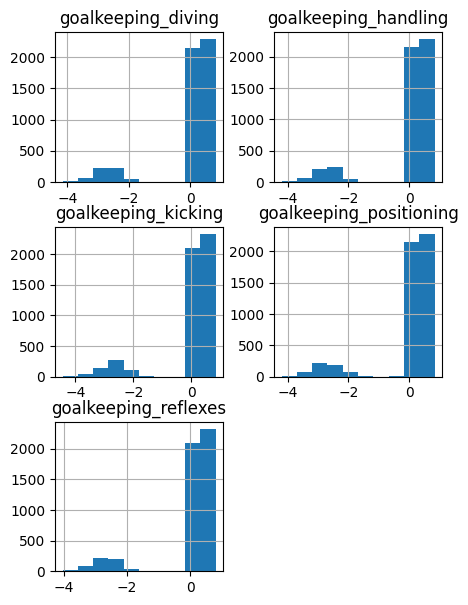

In [ ]:
# Experiment with flipping the goalkeeper statistics 
X_transformed = pd.DataFrame(preprocesser_simple.fit_transform(features_X, regression_target_Y), 
                             columns=numerical_features_X)

goal = [col for col in X_transformed.columns if 'goalkeeping' in col]

plt.clf()
X_transformed[goal].hist(figsize=(5, 7))
plt.show()

X_transformed = pd.DataFrame(preprocesser_flip.fit_transform(features_X, regression_target_Y), 
                             columns=numerical_features_X)

goal = [col for col in X_transformed.columns if 'goalkeeping' in col]

plt.clf()
X_transformed[goal].hist(figsize=(5,7))
plt.show()


In [259]:
# Evaluate

#regressor = SGDRegressor()
#regressor = KNeighborsRegressor(3)

regressor = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    learning_rate='adaptive',
    eta0=0.01,
    alpha=0.00001
)


clf_dumb = Pipeline(
    steps=[("preprocessor", preprocesser_dumb),
            ("regressor", regressor)]
)
clf = Pipeline(
    steps=[("preprocessor", preprocesser_simple),
            ("regressor", regressor)]
)
clf_flip = Pipeline(
    steps=[("preprocessor", preprocesser_flip),
            ("regressor", regressor)]
)
clf_pca = Pipeline(
    steps=[("preprocessor", preprocesser_pca),
            ("regressor", regressor)]
)
for model, name in zip([clf_dumb, clf, clf_flip, clf_pca],['dumb', 'simple', 'flip', 'pca']):
    model_score_results = []
    for i in range(100):

        X_train, X_test, y_train, y_test = train_test_split(
            features_X, regression_target_Y, test_size=0.2
        )

        model.fit(X_train, y_train)
        model_score_results.append(model.score(X_test, y_test))
    print(model_score_results)
    print(f"{name}_score avg", sum(model_score_results) / len(model_score_results))

[-2.5165674116827594e+21, -4.970480394303728e+20, -5.0643091637763545e+20, -7.45119265490853e+21, -6.360215563402076e+21, -1.3695593720971457e+23, -1.7878907092118324e+22, -4.195456492219327e+22, -6.600993068909699e+20, -1.5773816084970854e+22, -2.530098389872221e+22, -4.54080278457573e+20, -1.0234465006275028e+22, -1.1870695835443984e+22, -4.1887149208326347e+21, -2.49421169592222e+22, -2.2390188749568546e+21, -4.4939496954594125e+20, -2.3567266269863057e+22, -7.443867576246075e+22, -4.50473597168311e+22, -5.628647463433947e+21, -5.550445080311781e+21, -3.0601756118451407e+22, -4.571261853687892e+22, -2.653664692006714e+19, -7.691537627141349e+18, -8.365332496571864e+18, -4.999776713236244e+22, -1.0584624081672451e+20, -3.640393589262271e+22, -8.45519200732709e+21, -4.470668209286938e+22, -1.5124683664830292e+21, -9.150367891026859e+19, -1.3035773535360225e+23, -2.3185782077598863e+20, -1.564667355489654e+22, -2.0715502300297737e+22, -3.257237175501426e+22, -3.4315353157736293e+22, -1

### From the above results, we can conclude that flipping the goalkeeper scores w.r.t. the mean does little in the way of improving the score of the classifier. Meanwhile, the PCA pipeline reduces the score significantly (even on 0.95)

### Autograder 

In the autograder you will need to provide two things: 1) estimate of the MAE of your model on unseen data, 2) the predictions on the autograder data. For the autograder data we only provide the features and not the regression targets. Thus, you cannot compute the MAE on this data yourself - you need to estimate that with the data provided above. 

In [256]:
data_autograder = pd.read_csv('football_autograder.csv')
data_autograder.head()


,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_agility,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,27.0,190.0,78.0,b'England',70.0,71.0,52.0,42.0,75.0,60.0,...,57.0,67.0,61.0,72.0,68.0,15.0,8.0,12.0,13.0,15.0
1,19.0,183.0,76.0,b'Republic of Ireland',59.0,77.0,45.0,20.0,53.0,60.0,...,66.0,55.0,69.0,59.0,57.0,8.0,11.0,10.0,6.0,11.0
2,20.0,172.0,67.0,b'China PR',48.0,53.0,40.0,34.0,38.0,52.0,...,57.0,56.0,70.0,35.0,43.0,12.0,6.0,9.0,7.0,12.0
3,28.0,170.0,65.0,b'Brazil',76.0,76.0,73.0,76.0,52.0,72.0,...,89.0,70.0,88.0,50.0,48.0,12.0,7.0,12.0,10.0,7.0
4,28.0,186.0,74.0,b'England',65.0,67.0,18.0,19.0,15.0,25.0,...,32.0,57.0,57.0,14.0,17.0,66.0,64.0,66.0,63.0,68.0


In [257]:
# TODO Replace this with your own estimate of the MAE of your best model
estimate_MAE_on_new_data = np.array([1.0])

# TODO Replace this with the predictions of your best model
# via e.g. prediction = model.predict(data_autograder)
# your predictions here should again be the $log_{10}(wage)$ of the football player, just as in the provided data. 
predictions_autograder_data = np.array([-1] * 14178)

# Upload this file to the Vocareum autograder:
result = np.append(estimate_MAE_on_new_data, predictions_autograder_data)
pd.DataFrame(result).to_csv("autograder_submission.txt", index=False, header=False)